Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


#Check for null values in every columns and remove them

In [2]:
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
print(df.isnull().sum())
df.dropna(inplace=True)

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


#remove duplicates


In [3]:
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicates found: 23899


#Check for outliers using boxplot

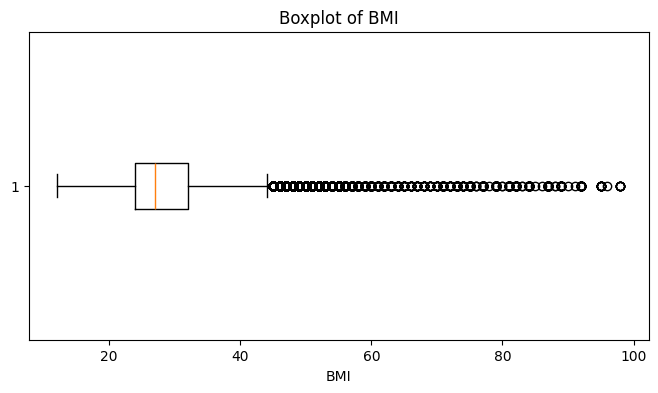

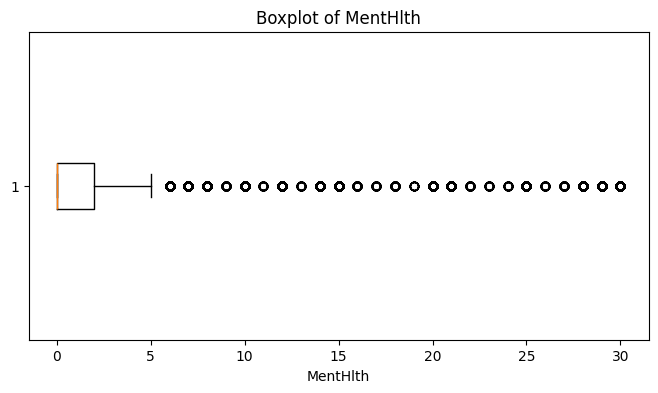

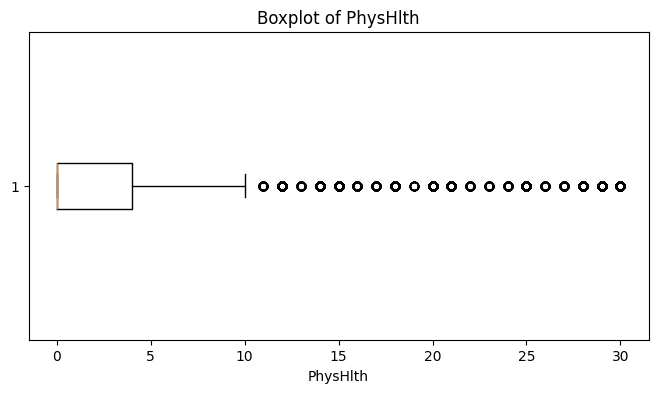

In [4]:
cols_to_check = ['BMI', 'MentHlth', 'PhysHlth']
for col in cols_to_check:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


# List of columns to clean

In [5]:
cols_to_clean = ['BMI', 'MentHlth', 'PhysHlth']

for col in cols_to_clean:
    # Calculate bounds
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # how many values fall outside these bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}' has {len(outliers)} values outside the IQR bounds.")
    
    # Clip the values to the lower and upper bounds
    # This prevents extreme outliers from skewing your model without deleting the row
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("\nOutlier treatment complete.")

Column 'BMI' has 5638 values outside the IQR bounds.
Column 'MentHlth' has 36163 values outside the IQR bounds.
Column 'PhysHlth' has 34347 values outside the IQR bounds.

Outlier treatment complete.


# Save the cleaned dataframe to a new file

In [6]:
df.to_csv('cleaned_diabetes_data.csv', index=False)

print("Cleaned data saved successfully as 'cleaned_diabetes_data.csv'")

Cleaned data saved successfully as 'cleaned_diabetes_data.csv'
